# Inter-Node Analysis

This notebook loads the capability tree for a specified dataset, and computes the Kendall's Taus between each node's local model ranking and the global model ranking.

Import packages.

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy.stats import kendalltau
from tqdm import tqdm
from utils.capability_tree import align_rankings, collect_nodes, load_capability_tree
from utils.data import Dataset
from utils.path import build_plot_path

Specify the dataset, load it's capability tree, and collect the tree's nodes.

In [82]:
dataset = Dataset.MATH
root = load_capability_tree(dataset)

Collect the capability tree's nodes.

In [83]:
min_instances = 50
global_ranking = root["ranking"]
nodes = collect_nodes(root, min_instances)

num_models = len(global_ranking)
print(f"Number of models: {num_models}")
print(f"Found {len(nodes)} nodes (non-root, size > {min_instances} instances)")

Number of models: 5
Found 74 nodes (non-root, size > 50 instances)


Compute the Kendall's Tau between each node's local model ranking and the global model ranking.

Computing Kendall's Taus: 100%|██████████| 74/74 [00:00<00:00, 3402.27node/s]


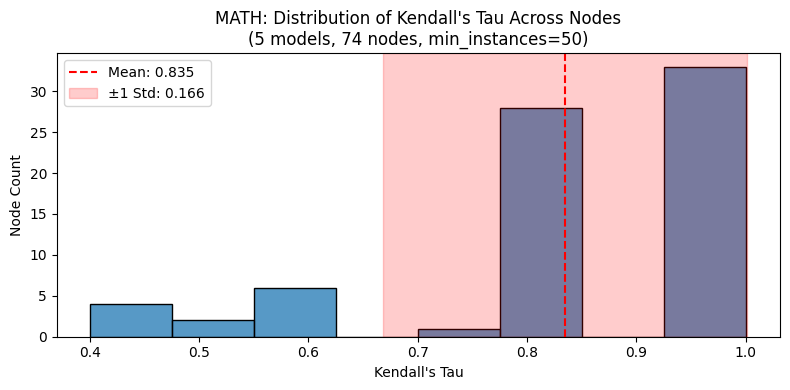

In [84]:
taus = []

kwargs = {
    "desc": "Computing Kendall's Taus",
    "total": len(nodes),
    "unit": "node",
}

for node in tqdm(nodes, **kwargs):
    global_vec, local_vec = align_rankings(global_ranking, node["ranking"])
    tau, _ = kendalltau(global_vec, local_vec)
    taus.append(tau)

# Compute mean and std
taus_arr = np.array(taus)
mean_tau = taus_arr.mean()
std_tau = taus_arr.std()

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(taus, ax=ax)

# Add vertical line at mean
ax.axvline(
    mean_tau,
    color="red",
    linestyle="--",
    label=f"Mean: {mean_tau:.3g}",
)

# Add shaded region for +/- 1 std
ax.axvspan(
    mean_tau - std_tau,
    mean_tau + std_tau,
    alpha=0.2,
    color="red",
    label=f"±1 Std: {std_tau:.3g}",
)

ax.set_xlabel("Kendall's Tau")
ax.set_ylabel("Node Count")
ax.set_title(
    f"{dataset}: Distribution of Kendall's Tau Across Nodes"
    f"\n({num_models} models, {len(nodes)} nodes, min_instances={min_instances})"
)
ax.legend()
plt.tight_layout()

plot_path = build_plot_path(
    dataset,
    analysis="inter_node_analysis",
    plot_name=f"kendall_tau_distribution-min_instances={min_instances}",
)
plt.savefig(plot_path)
plt.show()